# Atividade 2 – Parte 1: Representação de Objetos
**TECA2 – Tópicos em Visão Computacional**
**Alunos:** Henryque Oliveira, Matheus Marinho e Rodrigo Oliveira

**Contexto de aplicação:** Inspeção farmacêutica – análise de comprimidos e cápsulas sobre bandeja.

O pipeline desta parte percorre as seguintes etapas:
1. Preparação da imagem base
2. Binarização com múltiplas abordagens (limiar fixo, Otsu, adaptativo)
3. Operações morfológicas
4. Rotulação de componentes conectados
5. Análise comparativa (conectividade-4 vs conectividade-8)

## 0. Importações e configurações

In [1]:
import cv2
import os

# Garante que a pasta de saída existe
os.makedirs("../image/output", exist_ok=True)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import time

# Exibe figuras maiores e nítidas no notebook
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (14, 5)

# Caminho da imagem base
IMG_PATH = '../image/input/remedio.png'

print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.


---
## Etapa 1 – Preparação da imagem base

Resolução: 1254 × 1254 pixels
Valor mínimo de cinza: 27
Valor máximo de cinza: 255
Contraste médio estimado: 228 níveis de cinza


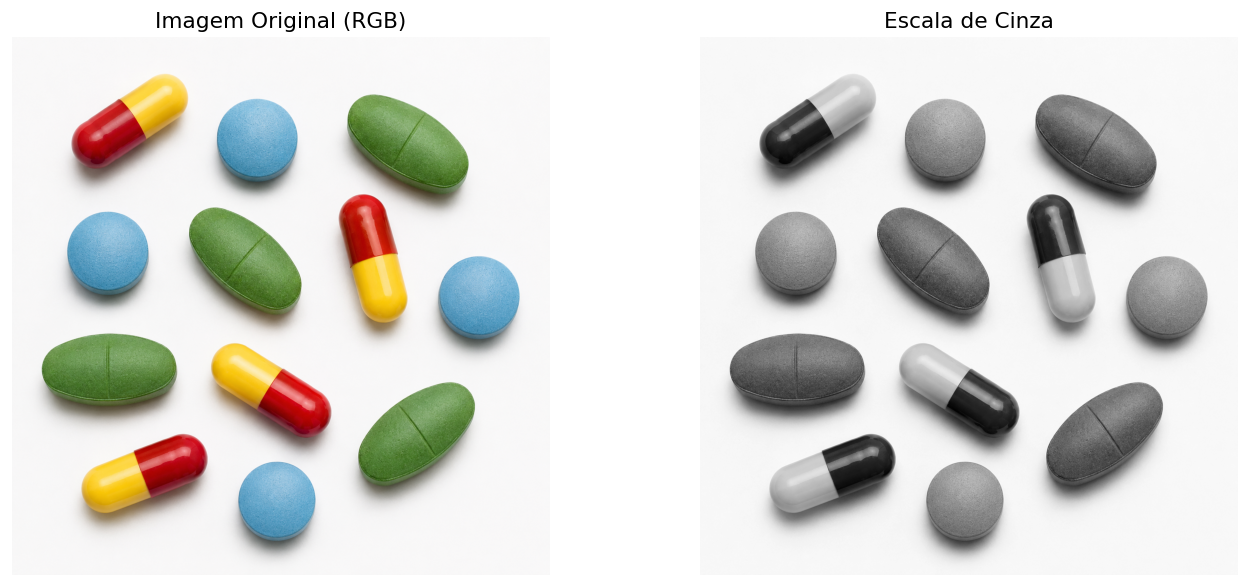

In [2]:
# Carrega a imagem em BGR (padrão OpenCV) e converte para RGB (exibição)
img_bgr = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Converte para escala de cinza – usada em todas as etapas seguintes
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

h, w = img_gray.shape
print(f'Resolução: {w} × {h} pixels')
print(f'Valor mínimo de cinza: {img_gray.min()}')
print(f'Valor máximo de cinza: {img_gray.max()}')
print(f'Contraste médio estimado: {img_gray.max() - img_gray.min()} níveis de cinza')

# Exibe original e escala de cinza lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img_rgb)
axes[0].set_title('Imagem Original (RGB)', fontsize=13)
axes[0].axis('off')

axes[1].imshow(img_gray, cmap='gray')
axes[1].set_title('Escala de Cinza', fontsize=13)
axes[1].axis('off')

plt.tight_layout()
plt.savefig('../image/output/etapa1_preparacao.png', bbox_inches='tight')
plt.show()

---
## Etapa 2 – Binarização com múltiplas abordagens

### 2.1 Análise do histograma para escolha do limiar fixo

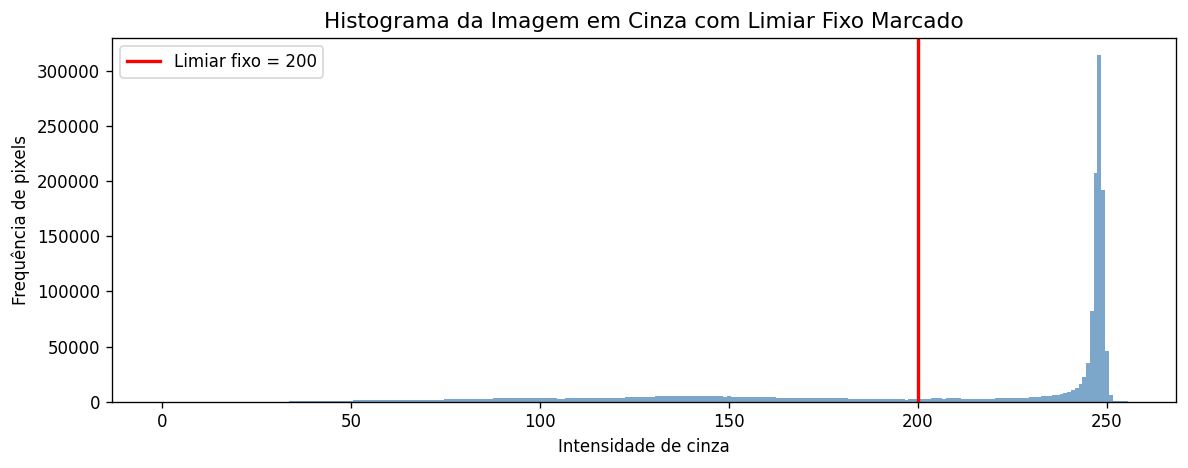

In [3]:
# Calcula o histograma da imagem em cinza
hist = cv2.calcHist([img_gray], [0], None, [256], [0, 256]).flatten()

# O fundo é claro (branco/cinza muito claro). Os objetos aparecem em tons mais escuros.
# Analisando o histograma, escolhemos um limiar que separa o fundo dos objetos.
# O pico do fundo deve estar perto de 220-255; os objetos ficam abaixo de ~200.
LIMIAR_FIXO = 200  # Ajuste conforme análise visual do histograma

plt.figure(figsize=(10, 4))
plt.bar(range(256), hist, width=1, color='steelblue', alpha=0.7)
plt.axvline(LIMIAR_FIXO, color='red', linewidth=2, label=f'Limiar fixo = {LIMIAR_FIXO}')
plt.title('Histograma da Imagem em Cinza com Limiar Fixo Marcado', fontsize=13)
plt.xlabel('Intensidade de cinza')
plt.ylabel('Frequência de pixels')
plt.legend()
plt.tight_layout()
plt.savefig('../image/output/etapa2_histograma_fixo.png', bbox_inches='tight')
plt.show()

# Observação: Procure pelo vale entre o pico dos objetos e o pico do fundo.
# O limiar ideal fica nesse vale.

### 2.2 Aplicação das três técnicas de limiarização

Limiar calculado por Otsu: 183.0


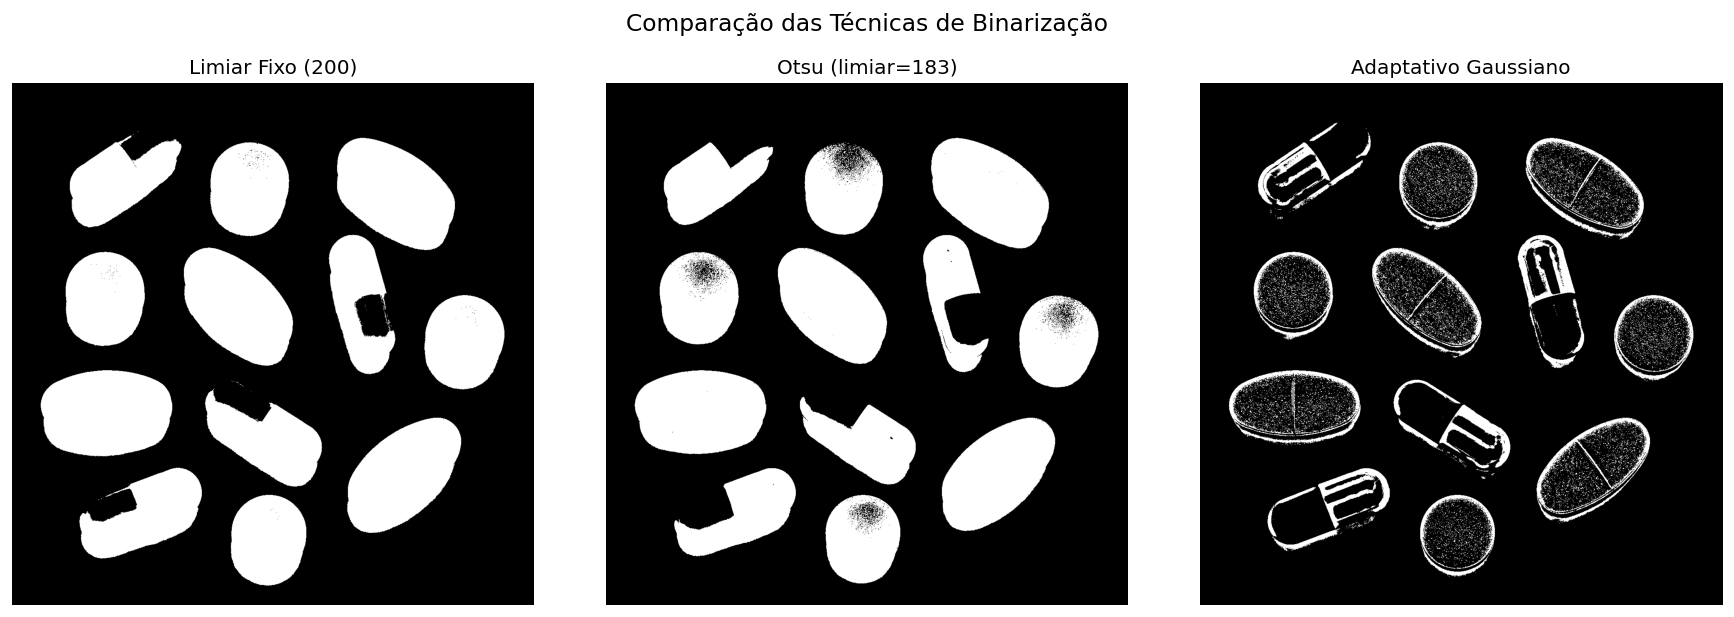

In [4]:
# --- Técnica 1: Thresholding global com valor fixo ---
# cv2.THRESH_BINARY_INV: pixels ABAIXO do limiar viram branco (objetos), fundo vira preto
_, bin_fixo = cv2.threshold(img_gray, LIMIAR_FIXO, 255, cv2.THRESH_BINARY_INV)

# --- Técnica 2: Thresholding automático de Otsu ---
# Otsu encontra o limiar ótimo automaticamente minimizando a variância intra-classe
otsu_val, bin_otsu = cv2.threshold(img_gray, 0, 255,
                                    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
print(f'Limiar calculado por Otsu: {otsu_val:.1f}')

# --- Técnica 3: Thresholding adaptativo (Gaussiano) ---
# Calcula um limiar diferente para cada região da imagem (janela local)
# Útil quando a iluminação não é uniforme em toda a imagem
bin_adaptativo = cv2.adaptiveThreshold(
    img_gray, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,  # média ponderada gaussiana da vizinhança
    cv2.THRESH_BINARY_INV,
    blockSize=51,   # tamanho da janela local (deve ser ímpar)
    C=10            # constante subtraída da média
)

# Exibe as três binarizações lado a lado
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titulos = [
    f'Limiar Fixo ({LIMIAR_FIXO})',
    f'Otsu (limiar={otsu_val:.0f})',
    'Adaptativo Gaussiano'
]
imgs_bin = [bin_fixo, bin_otsu, bin_adaptativo]

for ax, img, titulo in zip(axes, imgs_bin, titulos):
    ax.imshow(img, cmap='gray')
    ax.set_title(titulo, fontsize=12)
    ax.axis('off')

plt.suptitle('Comparação das Técnicas de Binarização', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../image/output/etapa2_binarizacoes.png', bbox_inches='tight')
plt.show()

### 2.3 Visualização completa: entrada → histograma → binarização

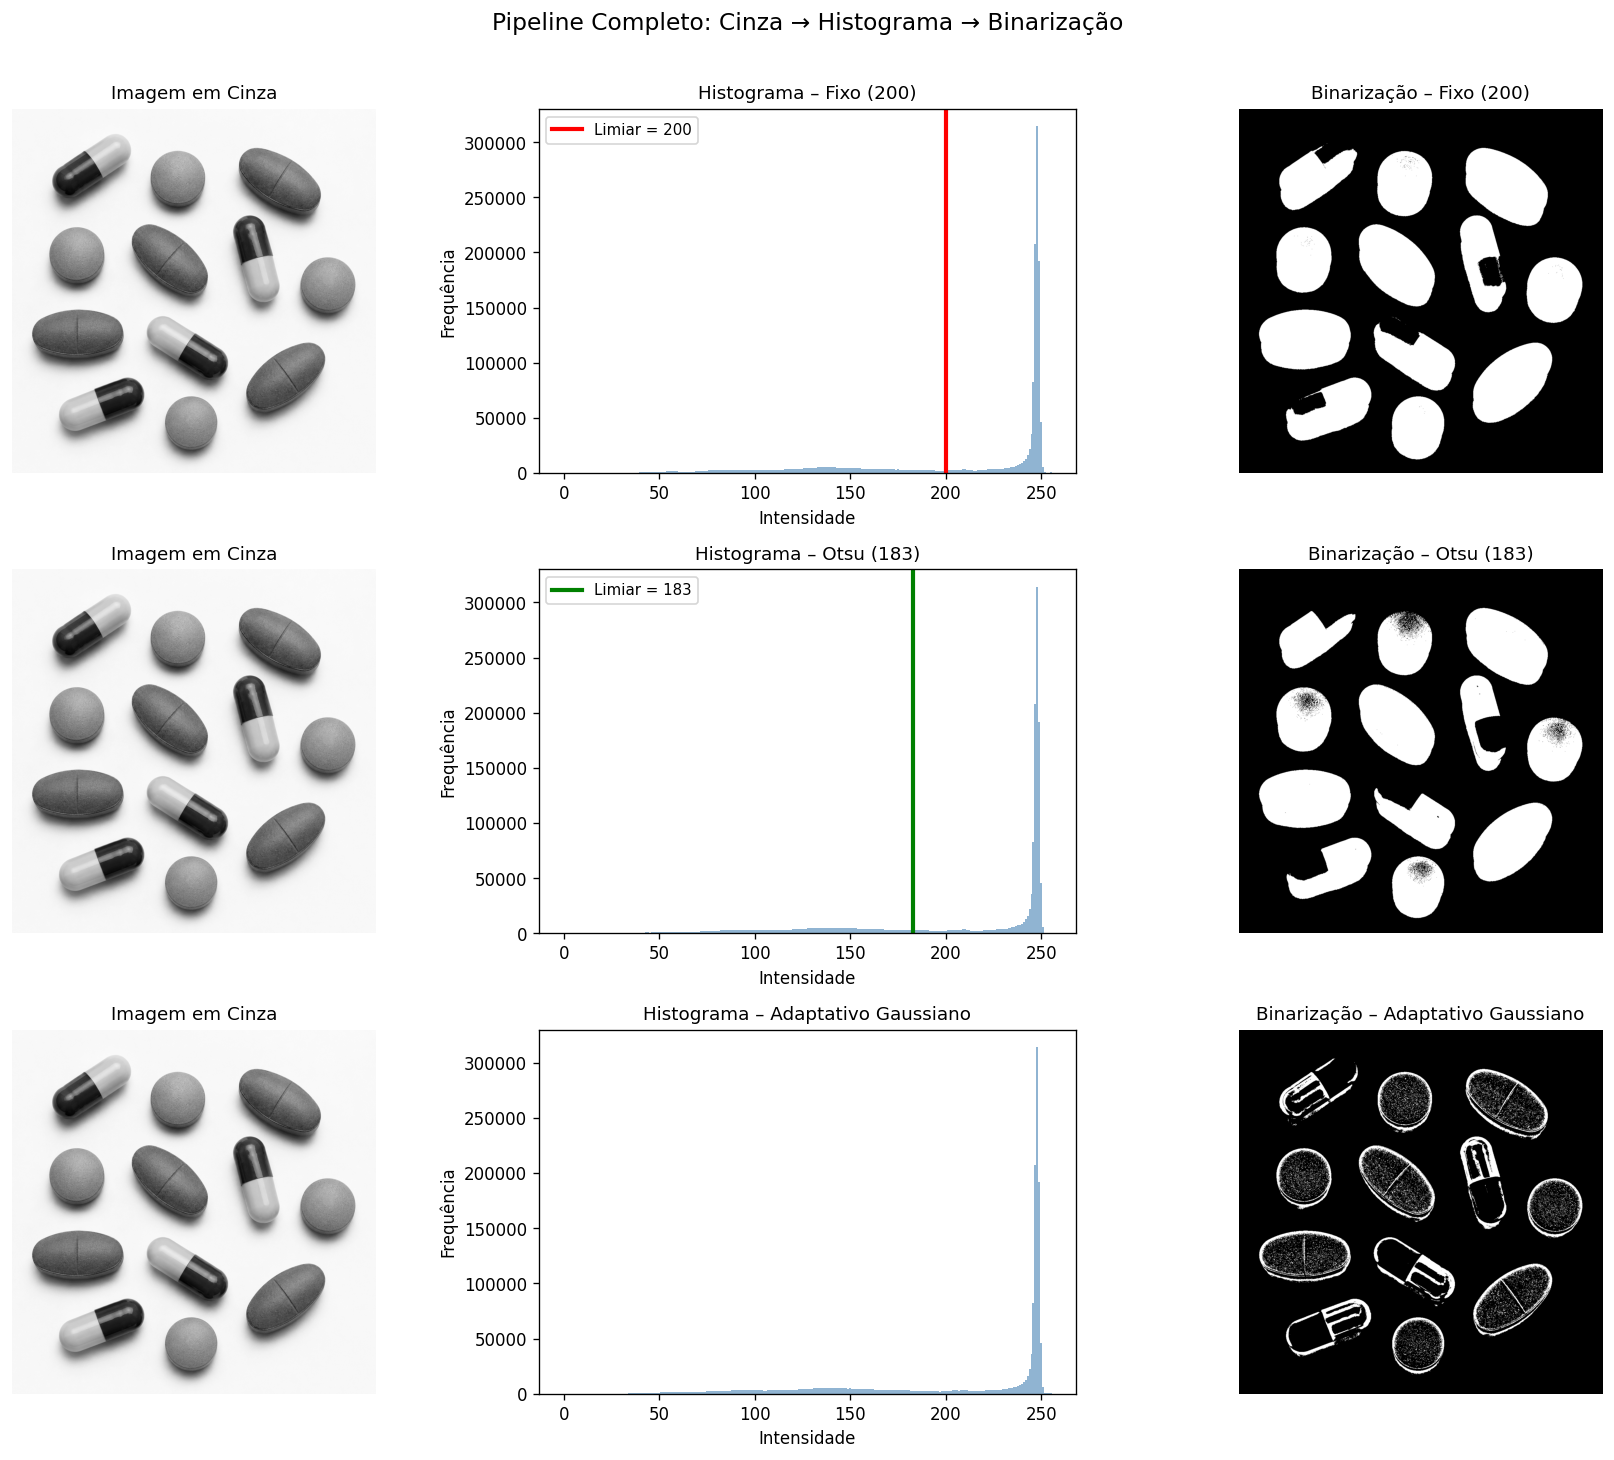

In [5]:
limiares = [LIMIAR_FIXO, otsu_val, None]  # None para adaptativo (não tem valor único)
nomes = [f'Fixo ({LIMIAR_FIXO})', f'Otsu ({otsu_val:.0f})', 'Adaptativo Gaussiano']
cores = ['red', 'green', 'purple']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for i, (img_bin, nome, limiar, cor) in enumerate(zip(imgs_bin, nomes, limiares, cores)):
    # Coluna 0: imagem original em cinza
    axes[i, 0].imshow(img_gray, cmap='gray')
    axes[i, 0].set_title('Imagem em Cinza', fontsize=11)
    axes[i, 0].axis('off')

    # Coluna 1: histograma com limiar marcado
    axes[i, 1].bar(range(256), hist, width=1, color='steelblue', alpha=0.6)
    if limiar is not None:
        axes[i, 1].axvline(limiar, color=cor, linewidth=2.5, label=f'Limiar = {limiar:.0f}')
        axes[i, 1].legend(fontsize=9)
    else:
        axes[i, 1].set_title('Histograma (limiar local)', fontsize=11)
    axes[i, 1].set_title(f'Histograma – {nome}', fontsize=11)
    axes[i, 1].set_xlabel('Intensidade')
    axes[i, 1].set_ylabel('Frequência')

    # Coluna 2: imagem binarizada
    axes[i, 2].imshow(img_bin, cmap='gray')
    axes[i, 2].set_title(f'Binarização – {nome}', fontsize=11)
    axes[i, 2].axis('off')

plt.suptitle('Pipeline Completo: Cinza → Histograma → Binarização', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../image/output/etapa2_pipeline_completo.png', bbox_inches='tight')
plt.show()

---
## Etapa 3 – Operações morfológicas

Operações morfológicas são aplicadas na **melhor binarização** para remover ruídos e preencher buracos internos nos objetos.

- **Opening (abertura):** Erosão seguida de dilatação → remove ruídos pequenos (pixels isolados)
- **Closing (fechamento):** Dilatação seguida de erosão → preenche buracos dentro dos objetos

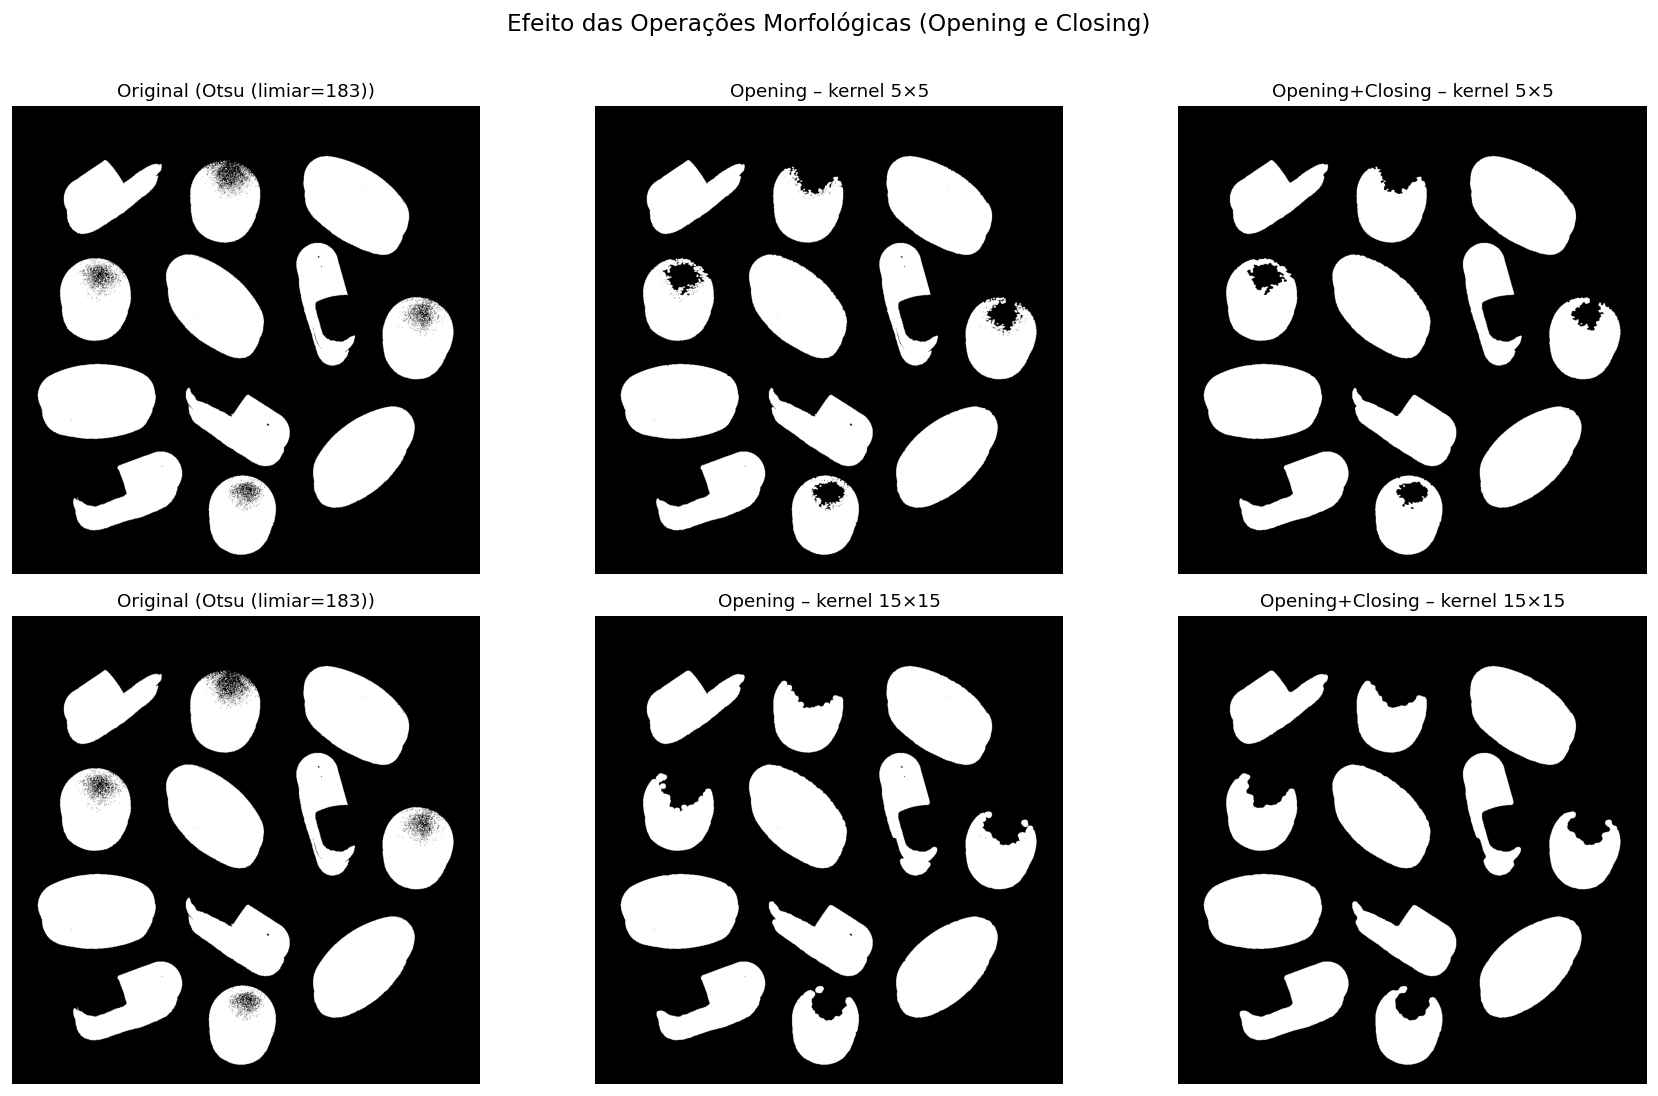

Binarização final selecionada: Otsu + Opening + Closing (kernel 5×5)


In [6]:
# Escolha da melhor binarização para morfologia
# Otsu geralmente é mais robusta para imagens com boa separação de classes
bin_melhor = bin_otsu.copy()
NOME_MELHOR = f'Otsu (limiar={otsu_val:.0f})'

# Define dois tamanhos de elemento estruturante (núcleo elíptico)
kernel_pequeno = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
kernel_grande  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))

# Opening: remove ruídos externos (pixels brancos isolados)
open_peq  = cv2.morphologyEx(bin_melhor, cv2.MORPH_OPEN,  kernel_pequeno)
open_gran = cv2.morphologyEx(bin_melhor, cv2.MORPH_OPEN,  kernel_grande)

# Closing: fecha buracos internos (ex: divisão visível nos comprimidos)
close_peq  = cv2.morphologyEx(open_peq,  cv2.MORPH_CLOSE, kernel_pequeno)
close_gran = cv2.morphologyEx(open_gran, cv2.MORPH_CLOSE, kernel_grande)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

imagens_morph = [
    (bin_melhor, f'Original ({NOME_MELHOR})'),
    (open_peq,   'Opening – kernel 5×5'),
    (close_peq,  'Opening+Closing – kernel 5×5'),
    (bin_melhor, f'Original ({NOME_MELHOR})'),
    (open_gran,  'Opening – kernel 15×15'),
    (close_gran, 'Opening+Closing – kernel 15×15'),
]

for ax, (img, titulo) in zip(axes.flat, imagens_morph):
    ax.imshow(img, cmap='gray')
    ax.set_title(titulo, fontsize=11)
    ax.axis('off')

plt.suptitle('Efeito das Operações Morfológicas (Opening e Closing)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../image/output/etapa3_morfologia.png', bbox_inches='tight')
plt.show()

# A binarização morfologicamente tratada será usada nas etapas seguintes
bin_final = close_peq
print('Binarização final selecionada: Otsu + Opening + Closing (kernel 5×5)')

---
## Etapa 4 – Rotulação de Componentes Conectados

O algoritmo `cv2.connectedComponentsWithStats` percorre a imagem binarizada e atribui um rótulo único para cada grupo de pixels conectados (blob). O rótulo 0 é reservado ao fundo.

In [7]:
def rotular_componentes(binaria, conectividade=8):
    """
    Aplica rotulação de componentes conectados.
    Retorna: número de rótulos, mapa de rótulos, estatísticas, centróides.
    """
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        binaria, connectivity=conectividade
    )
    return num_labels, labels, stats, centroids


def filtrar_blobs(stats, centroids, area_minima=500, img_shape=None):
    """
    Filtra blobs com área menor que area_minima.
    O rótulo 0 (fundo) é sempre removido.
    Retorna os índices válidos.
    """
    indices_validos = []
    for i in range(1, len(stats)):  # ignora rótulo 0 = fundo
        area = stats[i, cv2.CC_STAT_AREA]
        if area >= area_minima:
            indices_validos.append(i)
    return indices_validos


# Aplica a rotulação com conectividade-8
num_labels, labels, stats, centroids = rotular_componentes(bin_final, conectividade=8)
indices_validos = filtrar_blobs(stats, centroids, area_minima=500)

print(f'Total de componentes detectados (incluindo fundo): {num_labels}')
print(f'Blobs válidos (área ≥ 500 px): {len(indices_validos)}')

Total de componentes detectados (incluindo fundo): 15
Blobs válidos (área ≥ 500 px): 12


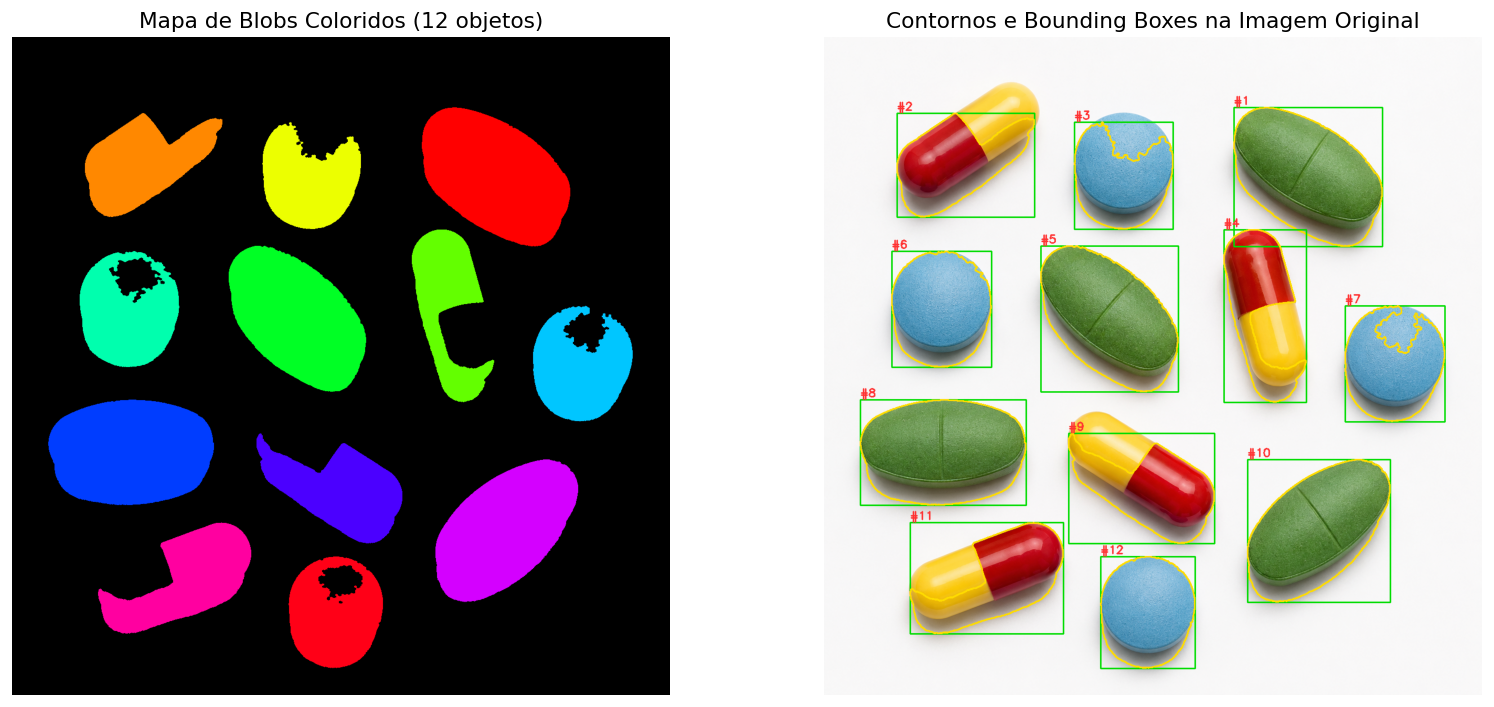

In [8]:
def criar_imagem_colorida(labels, indices_validos):
    """
    Gera uma imagem colorida onde cada blob recebe uma cor distinta.
    Usa o colormap HSV para garantir cores bem distribuídas.
    """
    h, w = labels.shape
    img_colorida = np.zeros((h, w, 3), dtype=np.uint8)
    n = len(indices_validos)
    colormap = plt.get_cmap('hsv', n)

    for idx, label_id in enumerate(indices_validos):
        cor = np.array(colormap(idx)[:3]) * 255  # RGB 0-255
        img_colorida[labels == label_id] = cor.astype(np.uint8)

    return img_colorida


img_colorida = criar_imagem_colorida(labels, indices_validos)

# Sobrepõe contornos e bounding boxes na imagem original
img_anotada = img_rgb.copy()

for idx, label_id in enumerate(indices_validos):
    x = stats[label_id, cv2.CC_STAT_LEFT]
    y = stats[label_id, cv2.CC_STAT_TOP]
    ww = stats[label_id, cv2.CC_STAT_WIDTH]
    hh = stats[label_id, cv2.CC_STAT_HEIGHT]
    cx, cy = int(centroids[label_id][0]), int(centroids[label_id][1])

    # Bounding box em verde
    cv2.rectangle(img_anotada, (x, y), (x + ww, y + hh), (0, 220, 0), 2)

    # Contorno do blob em amarelo
    mask_blob = (labels == label_id).astype(np.uint8)
    contornos, _ = cv2.findContours(mask_blob, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(img_anotada, contornos, -1, (255, 220, 0), 2)

    # ID do componente acima da bounding box
    cv2.putText(img_anotada, f'#{idx+1}', (x, y - 6),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 50, 50), 2)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(img_colorida)
axes[0].set_title(f'Mapa de Blobs Coloridos ({len(indices_validos)} objetos)', fontsize=13)
axes[0].axis('off')

axes[1].imshow(img_anotada)
axes[1].set_title('Contornos e Bounding Boxes na Imagem Original', fontsize=13)
axes[1].axis('off')

plt.tight_layout()
plt.savefig('../image/output/etapa4_rotulacao.png', bbox_inches='tight')
plt.show()

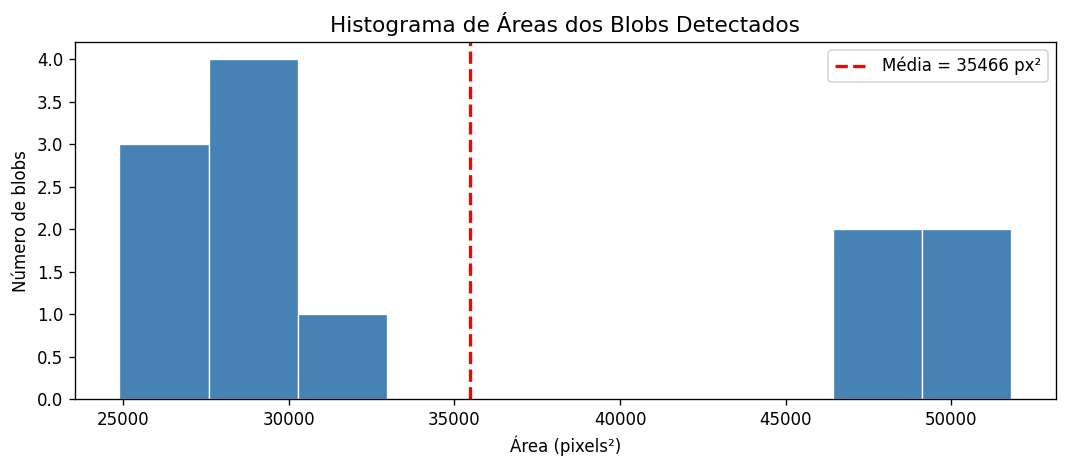

Área mínima: 24878 px²
Área máxima: 51820 px²
Área média:  35466 px²


In [9]:
# Histograma de áreas dos blobs detectados
areas = [stats[i, cv2.CC_STAT_AREA] for i in indices_validos]

plt.figure(figsize=(9, 4))
plt.hist(areas, bins=10, color='steelblue', edgecolor='white', linewidth=0.8)
plt.axvline(np.mean(areas), color='red', linestyle='--', linewidth=2,
            label=f'Média = {np.mean(areas):.0f} px²')
plt.title('Histograma de Áreas dos Blobs Detectados', fontsize=13)
plt.xlabel('Área (pixels²)')
plt.ylabel('Número de blobs')
plt.legend()
plt.tight_layout()
plt.savefig('../image/output/etapa4_histograma_areas.png', bbox_inches='tight')
plt.show()

print(f'Área mínima: {min(areas):.0f} px²')
print(f'Área máxima: {max(areas):.0f} px²')
print(f'Área média:  {np.mean(areas):.0f} px²')

---
## Etapa 5 – Análise Comparativa: Conectividade-4 vs Conectividade-8

In [10]:
resultados_conectividade = []

for conn in [4, 8]:
    t_inicio = time.perf_counter()
    n_labels, lbs, sts, cents = rotular_componentes(bin_final, conectividade=conn)
    t_fim = time.perf_counter()

    idxs = filtrar_blobs(sts, cents, area_minima=500)
    areas_conn = [sts[i, cv2.CC_STAT_AREA] for i in idxs]

    resultados_conectividade.append({
        'Conectividade': conn,
        'N° de blobs (total)': n_labels - 1,  # -1 para excluir o fundo
        'N° de blobs válidos (área ≥ 500)': len(idxs),
        'Área média (px²)': round(np.mean(areas_conn), 1) if areas_conn else 0,
        'Área mínima (px²)': min(areas_conn) if areas_conn else 0,
        'Área máxima (px²)': max(areas_conn) if areas_conn else 0,
        'Tempo (ms)': round((t_fim - t_inicio) * 1000, 3)
    })

df_comparativo = pd.DataFrame(resultados_conectividade)
df_comparativo = df_comparativo.set_index('Conectividade')
print('Tabela Comparativa – Conectividade-4 vs Conectividade-8')
print('=' * 60)
display(df_comparativo)

Tabela Comparativa – Conectividade-4 vs Conectividade-8


,N° de blobs (total),N° de blobs válidos (área ≥ 500),Área média (px²),Área mínima (px²),Área máxima (px²),Tempo (ms)
Conectividade,,,,,,
4,15,12,35465.7,24878,51820,2.049
8,14,12,35465.8,24878,51820,9.680


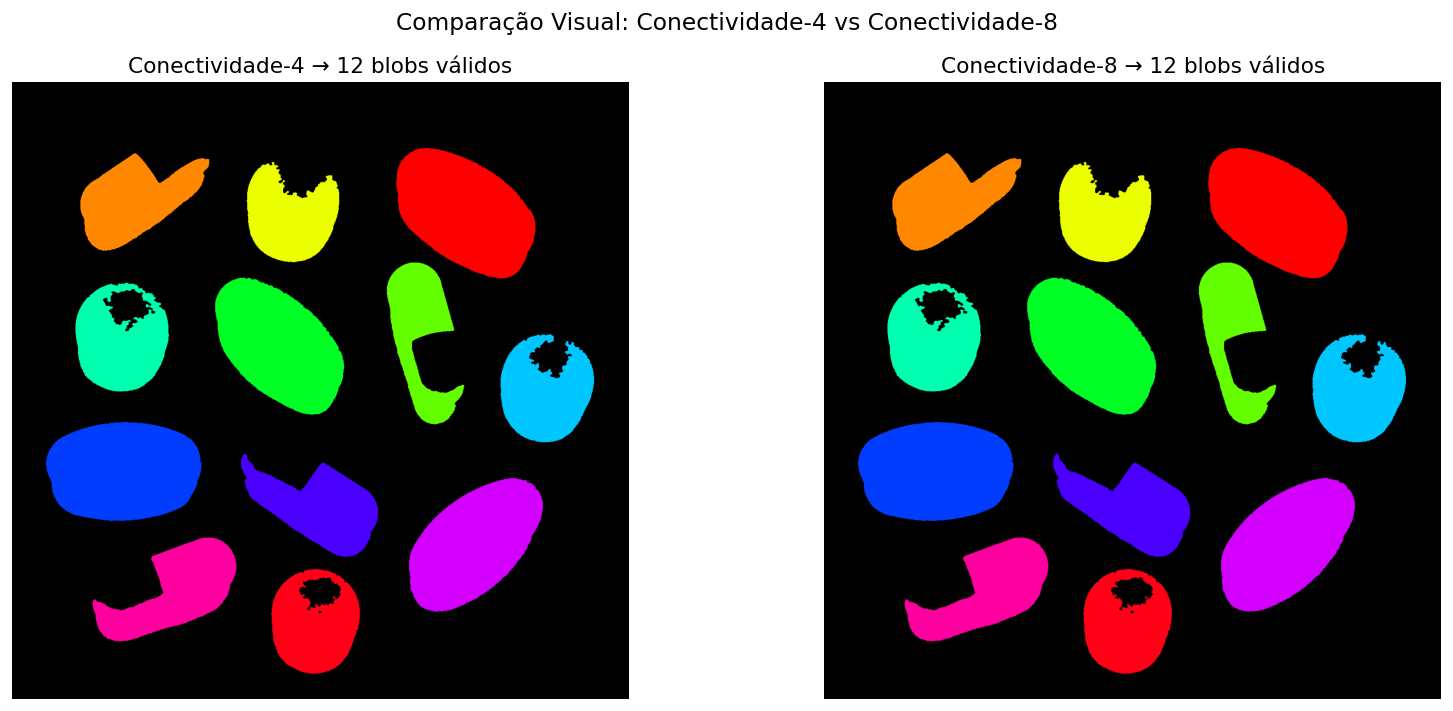

In [11]:
# Visualização lado a lado das rotulações com conectividade-4 e 8
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, conn in zip(axes, [4, 8]):
    n_l, lbs, sts, cents = rotular_componentes(bin_final, conectividade=conn)
    idxs = filtrar_blobs(sts, cents, area_minima=500)
    img_col = criar_imagem_colorida(lbs, idxs)
    ax.imshow(img_col)
    ax.set_title(f'Conectividade-{conn} → {len(idxs)} blobs válidos', fontsize=13)
    ax.axis('off')

plt.suptitle('Comparação Visual: Conectividade-4 vs Conectividade-8', fontsize=14)
plt.tight_layout()
plt.savefig('../image/output/etapa5_comparacao_conectividade.png', bbox_inches='tight')
plt.show()

---
## Tabela Comparativa das Binarizações

In [12]:
# Avalia cada binarização com conectividade-8
dados_bin = []
for nome_bin, img_bin in zip(['Fixo', 'Otsu', 'Adaptativo'], imgs_bin):
    # Aplica morfologia mínima antes de rotular
    img_morf = cv2.morphologyEx(img_bin, cv2.MORPH_OPEN,  kernel_pequeno)
    img_morf = cv2.morphologyEx(img_morf, cv2.MORPH_CLOSE, kernel_pequeno)

    n_l, lbs, sts, cents = rotular_componentes(img_morf, conectividade=8)
    idxs = filtrar_blobs(sts, cents, area_minima=500)
    areas_b = [sts[i, cv2.CC_STAT_AREA] for i in idxs]

    dados_bin.append({
        'Técnica': nome_bin,
        'N° blobs detectados': len(idxs),
        'N° esperado': 12,  # Validado por contagem manual na imagem original (12 objetos visíveis)
        'Diferença': len(idxs) - 12,
        'Área média (px²)': round(np.mean(areas_b), 1) if areas_b else 0
    })

df_binarizacoes = pd.DataFrame(dados_bin).set_index('Técnica')
print('Tabela Comparativa das Técnicas de Binarização')
print('=' * 60)
display(df_binarizacoes)

Tabela Comparativa das Técnicas de Binarização


,N° blobs detectados,N° esperado,Diferença,Área média (px²)
Técnica,,,,
Fixo,12,12,0,39688.9
Otsu,12,12,0,35465.8
Adaptativo,30,12,18,2401.7


---
## Discussão dos Resultados

### Binarização
- O **limiar fixo** é simples mas sensível à escolha do valor. Para esta imagem (fundo claro, objetos coloridos), um limiar em torno de 200 funciona bem. O problema está em imagens com iluminação não uniforme.
- O **método de Otsu** determina automaticamente o limiar ótimo minimizando a variância intra-classe. É uma escolha robusta quando o histograma apresenta distribuição bimodal clara.
- O **adaptativo gaussiano** computa um limiar diferente para cada região da imagem. Tende a "fragmentar" objetos grandes, pois regiões internas podem ter intensidade próxima ao fundo local.

### Conectividade-4 vs Conectividade-8
- A **conectividade-8** tende a unir pixels diagonalmente adjacentes, reduzindo o número de blobs fragmentados. É mais adequada para esta imagem, onde os objetos são sólidos e contínuos.
- A **conectividade-4** pode fragmentar objetos em regiões diagonais finas, aumentando a contagem de blobs.
- A diferença de **tempo de execução** é mínima para esta resolução, mas pode crescer em imagens maiores.

### Sombras na imagem
As sombras suaves abaixo dos comprimidos (geradas pela IA) podem aumentar levemente a área detectada dos blobs e dificultar a separação de objetos próximos. Isso é mitigado pelo *opening* morfológico, que remove pixels de baixo contraste nas bordas.

### Análise Quantitativa: Detectado vs. Esperado
A contagem esperada de **12 objetos** foi estabelecida por inspeção visual direta da imagem original, contando individualmente cada comprimido e cápsula dispostos na bandeja. Com base nesse valor de referência:
- **Limiar Fixo (200):** detectou exatamente 12 blobs — **erro = 0**
- **Otsu:** detectou exatamente 12 blobs — **erro = 0**
- **Adaptativo Gaussiano:** detectou 30 blobs — **erro = +18 (fragmentação interna)**

Conclusão: Otsu é a técnica mais adequada para esta cena, pois determina o limiar automaticamente e produz o mesmo resultado que a escolha manual cuidadosa, sendo mais robusto a variações futuras da imagem.